# Imports

In [1]:
import numpy as np 
import pandas as pd
from mggp import MGGP
import matplotlib.pyplot as plt
from utils.utils import *
from utils.utils_hysteresis import mcase_21

E:\projetos\mggp_model\src\mggp\base.py:719: SyntaxWarning: invalid escape sequence '\d'
  if re.search("q\d", tree[i].name):


# Execute

In [ ]:
save_model = "mggp_models/dissertacao_best_model_FR1.pkl"
OUTPUT_FEATURES = 3

# Load MGGP Model

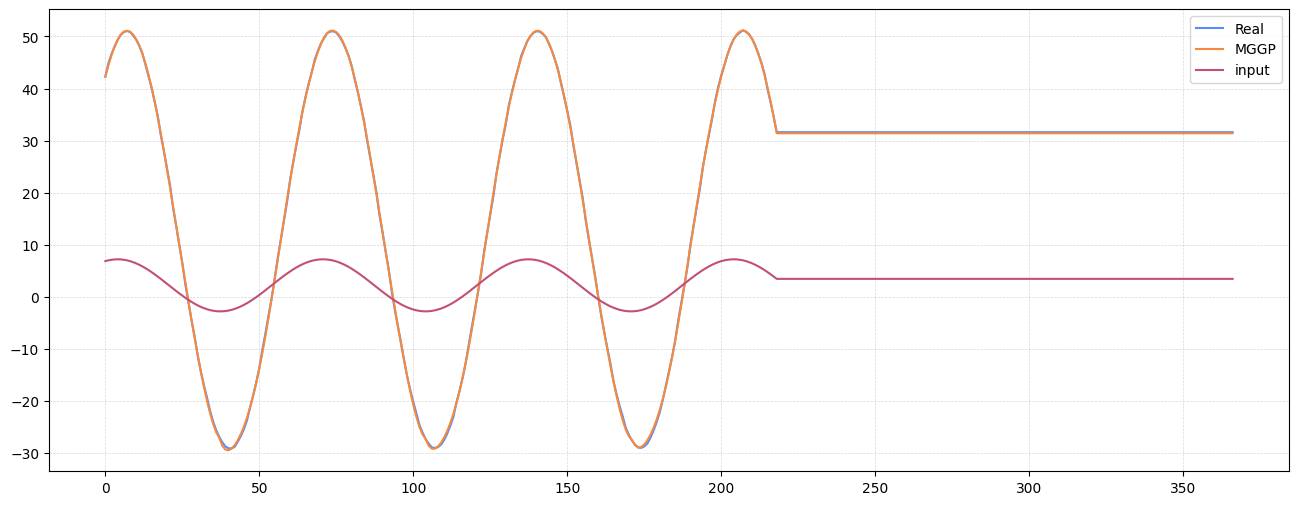

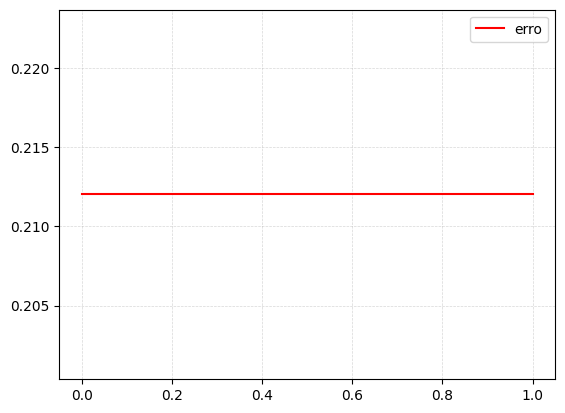

In [14]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 220
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split]
input = data[sinal_in][:split]

input = input.values.reshape(-1, 1)
output = output.values.reshape(-1, 1)

output_extend = np.repeat(output[-1], 150).reshape(-1, 1)
output = np.concatenate([output, output_extend], axis=0)

input_extend = np.repeat(input[-1], 150).reshape(-1, 1)
input = np.concatenate([input, input_extend], axis=0)

model_filename = "mggp_models_hysteresis_piezoeletric/mggp_24.pkl"
# model_filename = "mggp_models/hysteresis_model.pkl"
mggp_pred, mggp_yd = mggp_predict(X_val=input, 
                                  y_val=output, 
                                  # evaluationTypeTest='OSA',
                                  save_model=model_filename)

            
mggp_initial_conditions = len(output) - len(mggp_yd)
y_true_complete = output[mggp_initial_conditions:]
input_complete = input[mggp_initial_conditions:]
ypred_mcase = mcase_21(input, output)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase))

y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase[:min_length]

front = 200
plt.figure(figsize=(16, 6))
plt.plot(y_true_complete, label='Real')
plt.plot(mggp_pred_complete, label='MGGP')
plt.plot(input_complete, label='input')
# plt.plot(ypred_mcase1_complete, label='mcase', linestyle=':')
plt.grid(linestyle='--')
plt.legend()
plt.show()

# plt.figure(figsize=(16, 6))
# plt.plot(y_true_complete[250:], label='Real')
# plt.plot(mggp_pred_complete[250:], label='MGGP')
plt.plot(y_true_complete[-2:] - mggp_pred_complete[-2:], label='erro', color='r')
plt.grid(linestyle='--')
plt.legend()
plt.show()

In [9]:
folder = "Job1_2023_07_28_16_41_10_Mix"
# path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_medias_R_F_with_Fz_25.csv"
path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_extraidas_35_25.csv"
# u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, filter='_F$')
u_train, y_train, _, _ = load_data(path, 3, folder)

save_model = "mggp_models_hysteresis_piezoeletric/mggp_26.pkl"
# save_model = "mggp_models_hysteresis/mggp_10.pkl"
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            filename=save_model,
            operators=['mul', 'subtraction', 'sign']
            )

loaded_model = mggp.load_model()

print(mggp.simplify_model(loaded_model))

0.00000e+00 * 
2.02985e-01 * sign(u1[k] - u1[k-1]) * sign(u1[k] - u1[k-1]) * u1[k] +
2.70752e-01 * u1[k] * u1[k] * sign(u1[k] - u1[k-1]) +
1.00000e+00 * y1[k-1] +
-2.91556e+00 * (u1[k] - u1[k-1]) * u1[k-1] +
3.17353e-01 * y1[k-1] * (u1[k] - u1[k-1]) +
8.50955e-03 * (u1[k] - u1[k-1]) * y1[k-1] * y1[k-1] +
6.62914e-01 * sign(u1[k-1] - u1[k]) * sign(u1[k] - u1[k-1]) +
-9.82886e-02 * y1[k-1] * sign(u1[k] - u1[k-1]) +
1.96566e-01 * (u1[k] - u1[k-1]) * u1[k] * u1[k-1] +
-2.17844e-02 * u1[k] * u1[k] * u1[k] * sign(u1[k] - u1[k-1]) +
4.99725e-01 * u1[k] * sign(u1[k] - u1[k-1]) +
-1.04157e-01 * (u1[k] - u1[k-1]) * u1[k-1] * y1[k-1] +
-9.08256e-01 * (u1[k] - u1[k-1]) * (u1[k] - u1[k-1]) +
-4.45445e+00 * sign(u1[k] - u1[k-1]) +
1.70672e+01 * (u1[k] - u1[k-1]) +


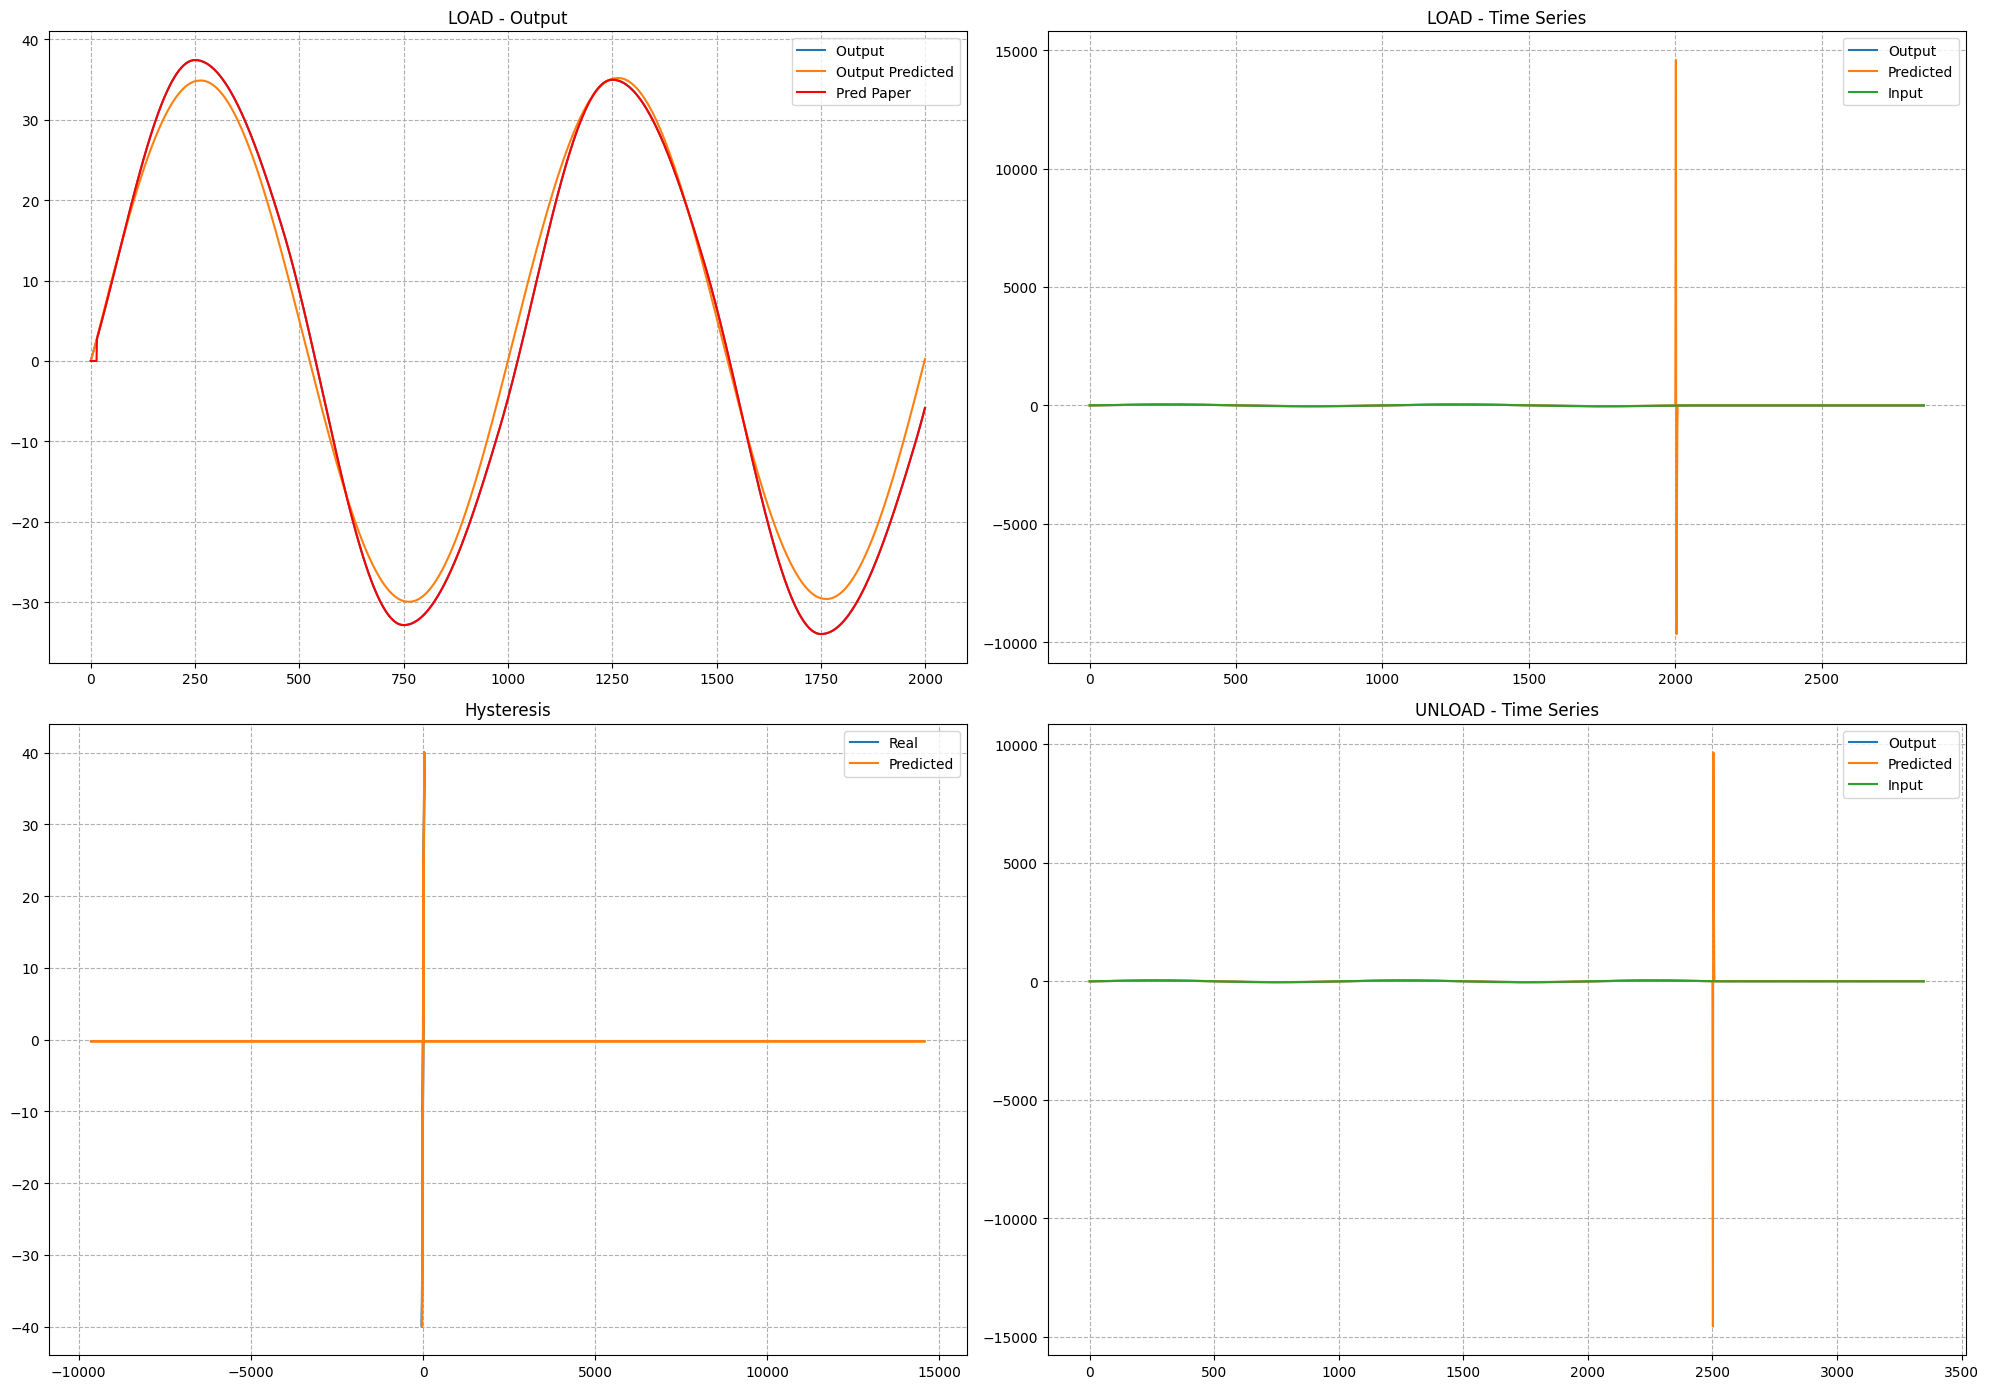

In [24]:
# Filter requirements.
fs = 1000       # sample rate, Hz
cutoff = 1     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
nyq = 0.5 * fs  # Nyquist Frequency
order = 5      # sin wave can be approx represented as quadratic

t = np.arange(0,101,1/fs)
seed = 93862723
np.random.seed(seed)
dataX = np.random.normal(0, 450, size=(len(t)))
dataX[0:1000] = 0
dataX[-1000:] = 0
u = butter_lowpass_filter(dataX, cutoff, fs, order)
u = u.reshape(-1)
udot = np.diff(u)/np.diff(t)
udot = udot[999:]
u_train = u[1000:]
t = t[1000:]

y_train = simulate(u_train, udot)

u_test = 40*np.sin(2*np.pi*t)
udot = np.diff(u_test)/np.diff(t)
y_test = simulate(u_test, udot)

u_train = np.array([u_train]).T
y_train = np.array([y_train]).T
u_test = np.array([u_test]).T
y_test = np.array([y_test]).T

# ===================== LOAD =====================
split = 2000

u_test_load = u_test[:split]
y_test_load = y_test[:split]

model_filename = "mggp_models_hysteresis/mggp_0.pkl"

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load, 
    y_val=y_test_load, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load) - len(mggp_yd)
y_true_complete = y_test_load[mggp_initial_conditions:]
ypred_mcase1 = mcase1(u_test_load, y_test_load)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]

plt.figure(figsize=(20, 14))

# --- LOAD: saída ---
plt.subplot(2, 2, 1)
plt.plot(y_true_complete, label='Output ')
plt.plot(mggp_pred_complete, label='Output Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.title("LOAD - Output")
plt.grid(linestyle='--')
plt.legend()

# Extensão (load)
y_test_extend = np.repeat(y_test_load[-1], 850).reshape(-1, 1)
y_test_load_ext = np.concatenate([y_test_load, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_load[-1], 850).reshape(-1, 1)
u_test_load_ext = np.concatenate([u_test_load, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load_ext, 
    y_val=y_test_load_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load_ext) - len(mggp_yd)
y_true_complete = y_test_load_ext[mggp_initial_conditions:]
input_complete = u_test_load_ext[mggp_initial_conditions:]
ypred_mcase1 = mcase1(u_test_load_ext, y_test_load_ext)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]


# --- LOAD: histerese ---
plt.subplot(2, 2, 2)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
# plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.plot(input_complete, label='Input')
plt.title("LOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_true_complete, input_complete, label='Real')
plt.plot(mggp_pred_complete, input_complete, label='Predicted')
plt.title("Hysteresis")
plt.grid(linestyle='--')
plt.legend()


# ===================== UNLOAD =====================
split = 2500

u_test_unload = u_test[:split]
y_test_unload = y_test[:split]

# Extensão (unload)
y_test_extend = np.repeat(y_test_unload[-1], 850).reshape(-1, 1)
y_test_unload_ext = np.concatenate([y_test_unload, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_unload[-1], 850).reshape(-1, 1)
u_test_unload_ext = np.concatenate([u_test_unload, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_unload_ext, 
    y_val=y_test_unload_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_unload_ext) - len(mggp_yd)
y_true_complete = y_test_unload_ext[mggp_initial_conditions:]
input_complete = u_test_unload_ext[mggp_initial_conditions:]

min_length = min(len(y_true_complete), len(mggp_pred))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]

# --- UNLOAD: time series ---
plt.subplot(2, 2, 4)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(input_complete, label='Input')
plt.title("UNLOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
folder = "Job1_2023_07_28_16_41_10_Mix"
# path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_medias_R_F_with_Fz_25.csv"
path = f"iTire road test data/{folder}/Tire_Features_extraidas_35_25.csv"
# u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, filter='_F$')
u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder)

# save_model = "mggp_models/mggp_test.pkl"
# save_model = "mggp_models_instant_nTerms_10_maxHeight_2/20_25/dissertacao_best_model_FR10.pkl"
save_model = "mggp_models_fir_instant/20_25/dissertacao_best_model_FR1.pkl"
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            filename=save_model)

loaded_model = mggp.load_model()

print(mggp.simplify_model(loaded_model))
# print(loaded_model)

Output 1:
2.98279e-01 * 
-4.86731e+00 * u13[i-1] +
3.52996e+01 * u24[i-1] +
-2.10803e+01 * u48[i-1] +
-1.33396e+02 * u19[i-1] +
-1.11255e+01 * u44[i-1] +
-2.77989e+01 * u5[i-1] +
-7.89946e+01 * u9[i-1] +
1.60644e+02 * u22[i-1] +
-1.36104e+02 * u32[i-1] +
-7.69834e+00 * u46[i-1] +
3.40628e+01 * u3[i-1] +
-1.75728e+01 * u39[i-1] +
8.78071e+01 * u28[i-1] +
6.13225e+01 * u20[i-1] +
-1.79014e+01 * u51[i-1] +
-1.95553e+01 * u37[i-1] +
6.62498e+01 * u2[i-1] +
-8.83876e+00 * u50[i-1] +
-7.09137e+01 * u17[i-1] +
4.98814e+01 * u7[i-1] +
Output 2:
-4.88643e-01 * 
-1.23001e+02 * u32[i-1] +
1.34979e+02 * u23[i-1] +
1.59644e+02 * u24[i-1] +
-1.11938e+02 * u33[i-1] +
-9.03413e+01 * u8[i-1] +
2.62375e+02 * u21[i-1] +
-5.27107e+01 * u14[i-1] +
-1.49138e+02 * u27[i-1] +
-1.25812e+02 * u10[i-1] +
-2.13184e+02 * u34[i-1] +
2.77236e+02 * u20[i-1] +
-7.24041e+01 * u9[i-1] +
2.28808e+02 * u26[i-1] +
-4.73010e+01 * u2[i-1] +
7.35495e+01 * u1[i-1] +
-1.84700e+02 * u30[i-1] +
-2.66543e+01 * u16[i-1] +
-5.96163e